In [1]:
import geopandas as gpd
import icechunk
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
# Configure S3 storage for the Icechunk repository
version = 'v1.1.0'
storage = icechunk.s3_storage(
    bucket='us-west-2.opendata.source.coop',
    prefix=f'carbonplan/carbonplan-ocr/output/fire-risk/tensor/production/{version}/ocr.icechunk',
    region='us-west-2',
    anonymous=True,
)

# Open the repository
repo = icechunk.Repository.open(storage)

# Create a read-only session on the main branch
session = repo.readonly_session('main')

ds = xr.open_dataset(session.store, engine='zarr', chunks='auto')
ds

<xarray.Dataset> Size: 652GB
Dimensions:        (latitude: 97579, longitude: 208881)
Coordinates:
  * latitude       (latitude) float64 781kB 22.43 22.43 22.43 ... 52.48 52.48
  * longitude      (longitude) float64 2MB -128.4 -128.4 ... -64.05 -64.05
Data variables:
    bp_2011        (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2047        (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2047_riley  (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2011_riley  (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    crps_scott     (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_scott      (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_2047       (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_2011       (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
Attributes:
    version:          1.1.0
    provider:         CarbonPlan
    terms_of_access:  https://docs.carbonplan.org/ocr/en/latest/terms-of-data...
    data_sources:     https://docs.carbonplan.org/ocr/en/latest/reference/dat...
    license_name:     CC-BY-4.0
    license_url:      https://creativecommons.org/licenses/by/4.0/

In [3]:
points_df = pd.read_csv('points-locations.csv')
points_df

,label,state,lat,lon
0,al_birmingham,AL,33.5186,-86.8104
1,al_talladega_nf,AL,33.4338,-86.1058
2,ar_fort_smith,AR,35.3859,-94.3985
3,ar_monticello,AR,33.6290,-91.7909
4,az_flagstaff,AZ,35.1983,-111.6513
...,...,...,...,...
95,wi_madison,WI,43.0731,-89.4012
96,wv_charleston,WV,38.3498,-81.6326
97,wv_elkins,WV,38.9259,-79.8467
98,wy_cheyenne,WY,41.1400,-104.8202



## Build the xarray point indexers

This is the key structure for vectorized `.sel()`:
- shared dimension name: point_location
- xarray indexers, not plain numpy arrays


In [4]:
points = xr.Dataset(
    data_vars={
        'latitude': (
            'point_location',
            points_df['lat'].to_numpy(dtype=float),
        ),
        'longitude': (
            'point_location',
            points_df['lon'].to_numpy(dtype=float),
        ),
    },
    coords={
        'point_location': points_df['label'].to_numpy(),
        'state': ('point_location', points_df['state'].to_numpy()),
    },
)

points

<xarray.Dataset> Size: 3kB
Dimensions:         (point_location: 100)
Coordinates:
  * point_location  (point_location) object 800B 'al_birmingham' ... 'wy_casper'
    state           (point_location) object 800B 'AL' 'AL' 'AR' ... 'WY' 'WY'
Data variables:
    latitude        (point_location) float64 800B 33.52 33.43 ... 41.14 42.85
    longitude       (point_location) float64 800B -86.81 -86.11 ... -106.3

## Vectorized nearest-neighbor selection


In [5]:
sampled = ds.sel(
    latitude=points.latitude,
    longitude=points.longitude,
    method='nearest',
)
sampled

<xarray.Dataset> Size: 6kB
Dimensions:         (point_location: 100)
Coordinates:
  * point_location  (point_location) object 800B 'al_birmingham' ... 'wy_casper'
    longitude       (point_location) float64 800B -86.81 -86.11 ... -106.3
    latitude        (point_location) float64 800B 33.52 33.43 ... 41.14 42.85
    state           (point_location) object 800B 'AL' 'AL' 'AR' ... 'WY' 'WY'
Data variables:
    bp_2011         (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    bp_2047         (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    bp_2047_riley   (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    bp_2011_riley   (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    crps_scott      (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    rps_scott       (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    rps_2047        (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    rps_2011        (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
Attributes:
    version:          1.1.0
    provider:         CarbonPlan
    terms_of_access:  https://docs.carbonplan.org/ocr/en/latest/terms-of-data...
    data_sources:     https://docs.carbonplan.org/ocr/en/latest/reference/dat...
    license_name:     CC-BY-4.0
    license_url:      https://creativecommons.org/licenses/by/4.0/

## Extract present-day and future risk, then rank

In [6]:
risk_df = (
    sampled[['rps_2011', 'rps_2047']]
    .to_dataframe()
    .reset_index()
    .rename(columns={'rps_2011': 'present_risk', 'rps_2047': 'future_risk'})[
        ['point_location', 'state', 'present_risk', 'future_risk']
    ]
)

risk_df['present_rank'] = risk_df['present_risk'].rank(ascending=False).astype(int)
risk_df['future_rank'] = risk_df['future_risk'].rank(ascending=False).astype(int)

risk_df = risk_df.sort_values('present_rank').reset_index(drop=True)
risk_df

,point_location,state,present_risk,future_risk,present_rank,future_rank
0,ca_julian_inland,CA,1.344096,3.251619,1,1
1,nm_ruidoso,NM,0.473532,0.768986,2,2
2,ca_mariposa_sierra,CA,0.217086,0.284374,3,3
3,nj_pinelands,NJ,0.172656,0.116588,4,8
4,az_payson,AZ,0.164299,0.227646,5,4
...,...,...,...,...,...,...
95,ny_albany,NY,0.000000,0.000000,73,73
96,oh_columbus,OH,0.000000,0.000000,73,73
97,ct_hartford,CT,0.000000,0.000000,73,73
98,nd_bismarck,ND,0.000000,0.000000,73,73


## Visualizations

### Map: present-day fire risk across all 100 locations

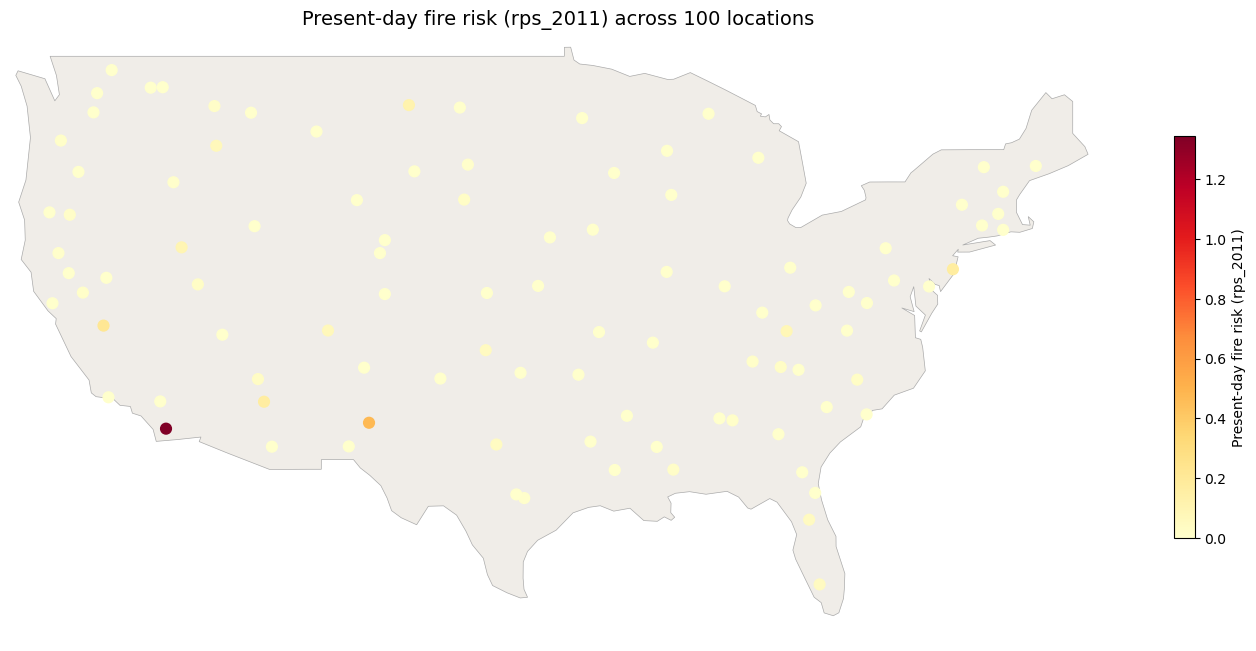

In [7]:
# Build GeoDataFrame from risk_df + original lat/lon
merged = risk_df.merge(
    points_df[['label', 'lat', 'lon']], left_on='point_location', right_on='label'
)
gdf = gpd.GeoDataFrame(
    merged,
    geometry=gpd.points_from_xy(merged['lon'], merged['lat']),
    crs='EPSG:4326',
)

# CONUS boundary from Natural Earth (direct URL, works with GeoPandas 1.0+)
ne_url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(ne_url)
conus = world[world['ISO_A3'] == 'USA']

fig, ax = plt.subplots(figsize=(14, 7))
conus.plot(ax=ax, color='#f0ede8', edgecolor='#aaa', linewidth=0.5)
gdf.plot(
    ax=ax,
    column='present_risk',
    cmap='YlOrRd',
    markersize=60,
    legend=True,
    legend_kwds={'label': 'Present-day fire risk (rps_2011)', 'shrink': 0.6},
)
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_title('Present-day fire risk (rps_2011) across 100 locations', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Scatter: present-day vs. future risk

Each point is a location. Points above the diagonal are getting riskier by 2047.

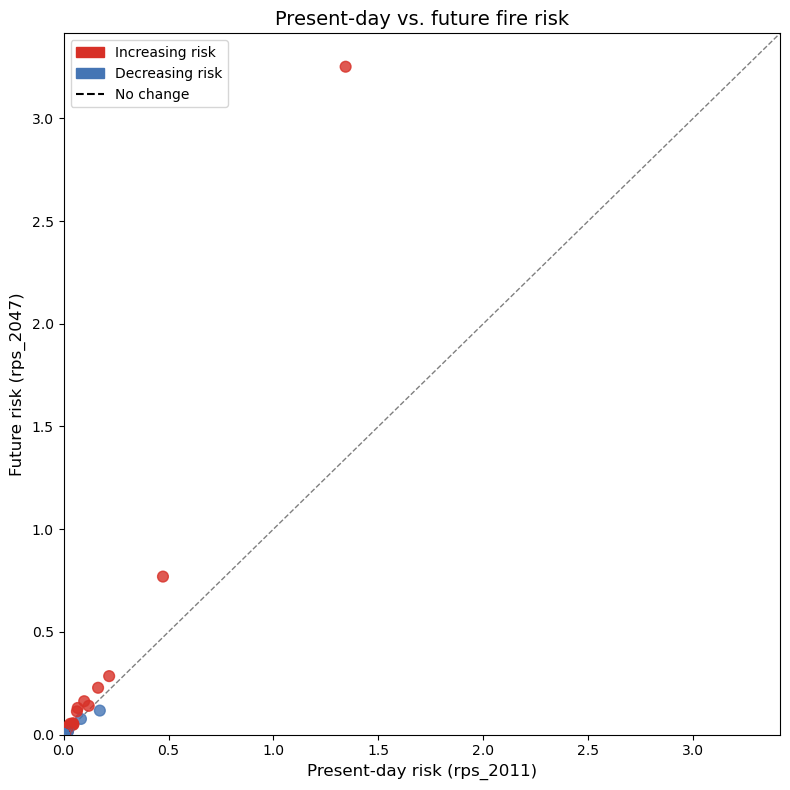

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

risk_change = risk_df['future_risk'] - risk_df['present_risk']
colors = np.where(risk_change > 0, '#d73027', '#4575b4')  # red = increasing, blue = decreasing

ax.scatter(risk_df['present_risk'], risk_df['future_risk'], c=colors, s=60, alpha=0.8, zorder=3)

# 1:1 diagonal (no change line)
lim_max = max(risk_df[['present_risk', 'future_risk']].max()) * 1.05
lim_min = min(risk_df[['present_risk', 'future_risk']].min()) * 0.95
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1, alpha=0.5, label='No change')
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

ax.set_xlabel('Present-day risk (rps_2011)', fontsize=12)
ax.set_ylabel('Future risk (rps_2047)', fontsize=12)
ax.set_title('Present-day vs. future fire risk', fontsize=14)

increasing = mpatches.Patch(color='#d73027', label='Increasing risk')
decreasing = mpatches.Patch(color='#4575b4', label='Decreasing risk')
ax.legend(
    handles=[
        increasing,
        decreasing,
        plt.Line2D([], [], color='k', linestyle='--', label='No change'),
    ]
)

plt.tight_layout()
plt.show()

### Bar chart: top 20 locations by present-day risk, colored by risk change

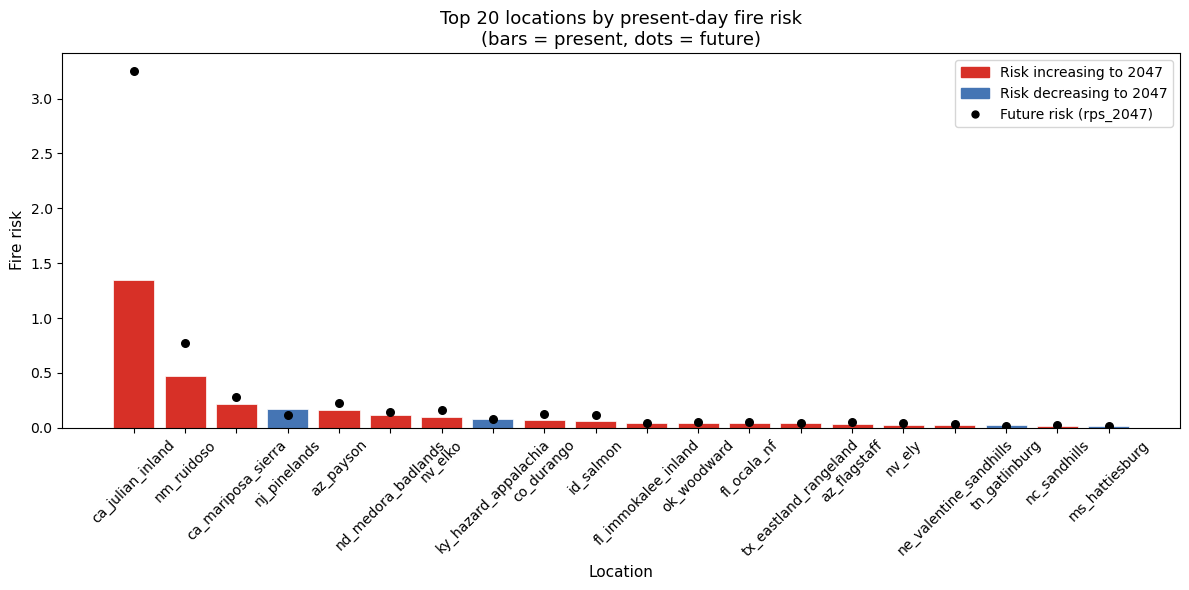

In [9]:
top20 = risk_df.head(20).copy()
top20['risk_change'] = top20['future_risk'] - top20['present_risk']
bar_colors = ['#d73027' if v > 0 else '#4575b4' for v in top20['risk_change']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    top20['point_location'],
    top20['present_risk'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
)

# Overlay future risk as a step/dot
ax.scatter(
    top20['point_location'],
    top20['future_risk'],
    color='black',
    zorder=5,
    s=30,
    label='Future risk (rps_2047)',
)

ax.set_xlabel('Location', fontsize=11)
ax.set_ylabel('Fire risk', fontsize=11)
ax.set_title(
    'Top 20 locations by present-day fire risk\n(bars = present, dots = future)', fontsize=13
)
ax.tick_params(axis='x', rotation=45)

increasing = mpatches.Patch(color='#d73027', label='Risk increasing to 2047')
decreasing = mpatches.Patch(color='#4575b4', label='Risk decreasing to 2047')
ax.legend(
    handles=[
        increasing,
        decreasing,
        plt.Line2D(
            [],
            [],
            color='black',
            marker='o',
            linestyle='',
            markersize=5,
            label='Future risk (rps_2047)',
        ),
    ]
)

plt.tight_layout()
plt.show()